In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, tqdm, glob
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import optax
from flax import nnx
import orbax.checkpoint as ocp

from jaxpm import camels, data, plotting, graph
from jaxpm.painting import cic_paint, cic_read
from jaxpm.nn import MLP, CNN, HybridNet, AttentionGNN

jax.devices("gpu")

[cuda(id=0)]

# functions

## training

In [3]:
@nnx.jit
def train_step(model, optimizer, x, y):

    def loss_fn(model):
        y_pred = model(*x, training=True)
        return jnp.mean((y - y_pred) **2)

    loss, grads = nnx.value_and_grad(loss_fn)(model)
    optimizer.update(grads)

    return loss

@nnx.jit
def vali_loop(model, X, Y):
    losses = []
    for i in range(scales.shape[0]):
        x, y = tuple(x[i] for x in X), Y[i]
        
        losses.append(jnp.mean((y - model(*x))**2))
    losses = jnp.mean(jnp.stack(losses))

    return losses
    
# NOTE this is GD, not SGD. There's no batches, all particles in the snapshot are evaluated every step
def train_model(
    model, 
    X,
    Y,
    X_vali,
    Y_vali,
    total_steps=10_000,
    vali_every=100,
    learning_rate=1e-3,
    cosine_decay=True,
):
    optimizer = optax.chain(
        optax.clip_by_global_norm(1),
        optax.adam(learning_rate)
    )
    optimizer = nnx.Optimizer(model, optimizer)

    if cosine_decay:
        learning_rate = optax.cosine_decay_schedule(
            init_value=learning_rate, 
            decay_steps=total_steps, 
            alpha=0.1
        )

    losses = []
    vali_steps = []
    vali_losses = []
    vali_loss = np.inf
    for i in (pbar := tqdm.tqdm(range(total_steps))):
        # select single snapshot
        j = np.random.choice(np.arange(scales.shape[0]))
        x, y = tuple(x[j] for x in X), Y[j]
        
        loss = train_step(model, optimizer, x, y)
        losses.append(loss)

        if (i % vali_every == 0) and (i != 0) or i == total_steps - 1:
            vali_steps.append(i)
            vali_loss = vali_loop(model, X_vali, Y_vali)
            vali_losses.append(vali_loss)

        pbar.set_description(f"train={loss:.4f}, vali={vali_loss:.4f}")

    fig, ax = plt.subplots()
    ax.plot(losses, label="training")
    ax.plot(vali_steps, vali_losses, label="validation")
    ax.legend(loc="upper right")
    ax.set(yscale="log")
    

## plotting

In [4]:
def plot_preds(pred, label, pred_vali, label_vali):
    nrows = pred_vali.shape[0]
    ncols = 2
    
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(2*ncols,2*nrows))

    # fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(2*ncols,2*nrows))
    # ncols = y_true.shape[-1]

    for i in range(nrows):
        ax[i,0].scatter(label[i], pred[i], s=0.1, color="tab:blue")
    
        ax[i,0].plot([label[i].min(), label[i].max()], [label[i].min(), label[i].max()], color="k", linestyle="--")
        ax[i,0].set_aspect("equal")
        ax[i,0].set_box_aspect(1)
        # ax[i].set_yticks(ax[i].get_xticks())

    ax[0,0].set(title="training")
    
    for i in range(nrows):
        ax[i,1].scatter(label_vali[i], pred_vali[i], s=0.1, color="tab:orange")
    
        ax[i,1].plot([label_vali[i].min(), label_vali[i].max()], [label_vali[i].min(), label_vali[i].max()], color="k", linestyle="--")
        ax[i,1].set_aspect("equal")
        ax[i,1].set_box_aspect(1)
        # ax[i].set_yticks(ax[i].get_xticks())
    
    ax[0,1].set(title="validation")

    fig.tight_layout()

In [5]:
def normalized_paint(positions, weights):
    N_pos = cic_paint(jnp.zeros([mesh_per_dim] * 3), positions)
    pos_N = cic_read(N_pos, positions)

    return cic_paint(jnp.zeros(mesh_shape), positions, weights/pos_N)


def plot_field(field, ax, vlims=None):
    log_sum = jnp.log10(field.sum(axis=0))

    if vlims is None:
        vmin, vmax = log_sum.min(), log_sum.max()
        vlims = (vmin, vmax)
    else:
        vmin, vmax = vlims
    
    return ax.imshow(log_sum, cmap="magma", vmin=vmin, vmax=vmax), vlims, log_sum


def plot_comparison(true_field, pred_field, true_label="CAMELS", pred_label="", quantity_label="P", suptitle=""):
    fig, ax = plt.subplots(figsize=(3*6, 6+1), ncols=3)
    
    im, vlims, true_field_log_sum = plot_field(true_field, ax[0])
    ax[0].set(title=true_label)
    
    im, _, pred_field_log_sum = plot_field(pred_field, ax[1], vlims=vlims)
    ax[1].set(title=pred_label)
    
    fig.colorbar(im, ax=ax[:2], label=f"log(sum({quantity_label}))", orientation="horizontal", shrink=0.6, aspect=20)
    
    residual = true_field_log_sum - pred_field_log_sum
    lim = np.max(np.abs(residual[np.isfinite(residual)]))
    print(lim)
    im = ax[2].imshow(residual, cmap="seismic", vmin=-lim, vmax=lim)
    ax[2].set(title="residual (true - pred)")
    fig.colorbar(im, ax=ax[2], label=f"log(sum({quantity_label}_1)) - log(sum({quantity_label}_2))", orientation="horizontal", shrink=0.6, aspect=10)
    
    for i in range(len(ax)):
        ax[i].set_yticks([])
        ax[i].set_xticks([])
    
    fig.suptitle(suptitle, fontsize=16)

In [6]:
parts_per_dim = 64
mesh_per_dim = parts_per_dim
mesh_shape = [mesh_per_dim] * 3

## CAMELS snapshots

In [7]:
# i_snapshots = [-2, -1]
i_snapshots = range(1, 33+4, 4)
# i_snapshots = None

In [8]:
# SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0"
SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/Astrid/CV/CV_0"

train_dict = camels.load_CV_snapshots(
    SIM,
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
)

Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/Astrid/CV/CV_0/snapshot_002.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/Astrid/CV/CV_0/snapshot_010.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/Astrid/CV/CV_0/snapshot_018.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/Astrid/CV/CV_0/snapshot_026.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/Astrid/CV/CV_0/snapshot_034.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/Astrid/CV/CV_0/snapshot_042.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/Astrid/CV/CV_0/snapshot_050.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/Astrid/CV/CV_0/snapshot_058.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/Astrid/CV/CV_0/snapshot_066.hdf5']
Selecting 262144 dark matter (deterministic)
Selecting 262144 gas particles (random)


finding unique gas particle indices: 100%|██████████| 9/9 [00:42<00:00,  4.77s/it]


There are 16726641 (99.70%) gas particles that exist in all snapshots


loading snapshots: 100%|██████████| 9/9 [01:27<00:00,  9.68s/it]


In [9]:
SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_1"
SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/Astrid/CV/CV_1"

test_dict = camels.load_CV_snapshots(
    SIM,
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
)

Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/Astrid/CV/CV_1/snapshot_002.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/Astrid/CV/CV_1/snapshot_010.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/Astrid/CV/CV_1/snapshot_018.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/Astrid/CV/CV_1/snapshot_026.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/Astrid/CV/CV_1/snapshot_034.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/Astrid/CV/CV_1/snapshot_042.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/Astrid/CV/CV_1/snapshot_050.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/Astrid/CV/CV_1/snapshot_058.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/Astrid/CV/CV_1/snapshot_066.hdf5']
Selecting 262144 dark matter (deterministic)
Selecting 262144 gas particles (random)


finding unique gas particle indices: 100%|██████████| 9/9 [00:42<00:00,  4.68s/it]


There are 16732953 (99.74%) gas particles that exist in all snapshots


loading snapshots: 100%|██████████| 9/9 [01:23<00:00,  9.30s/it]


# Preprocessing

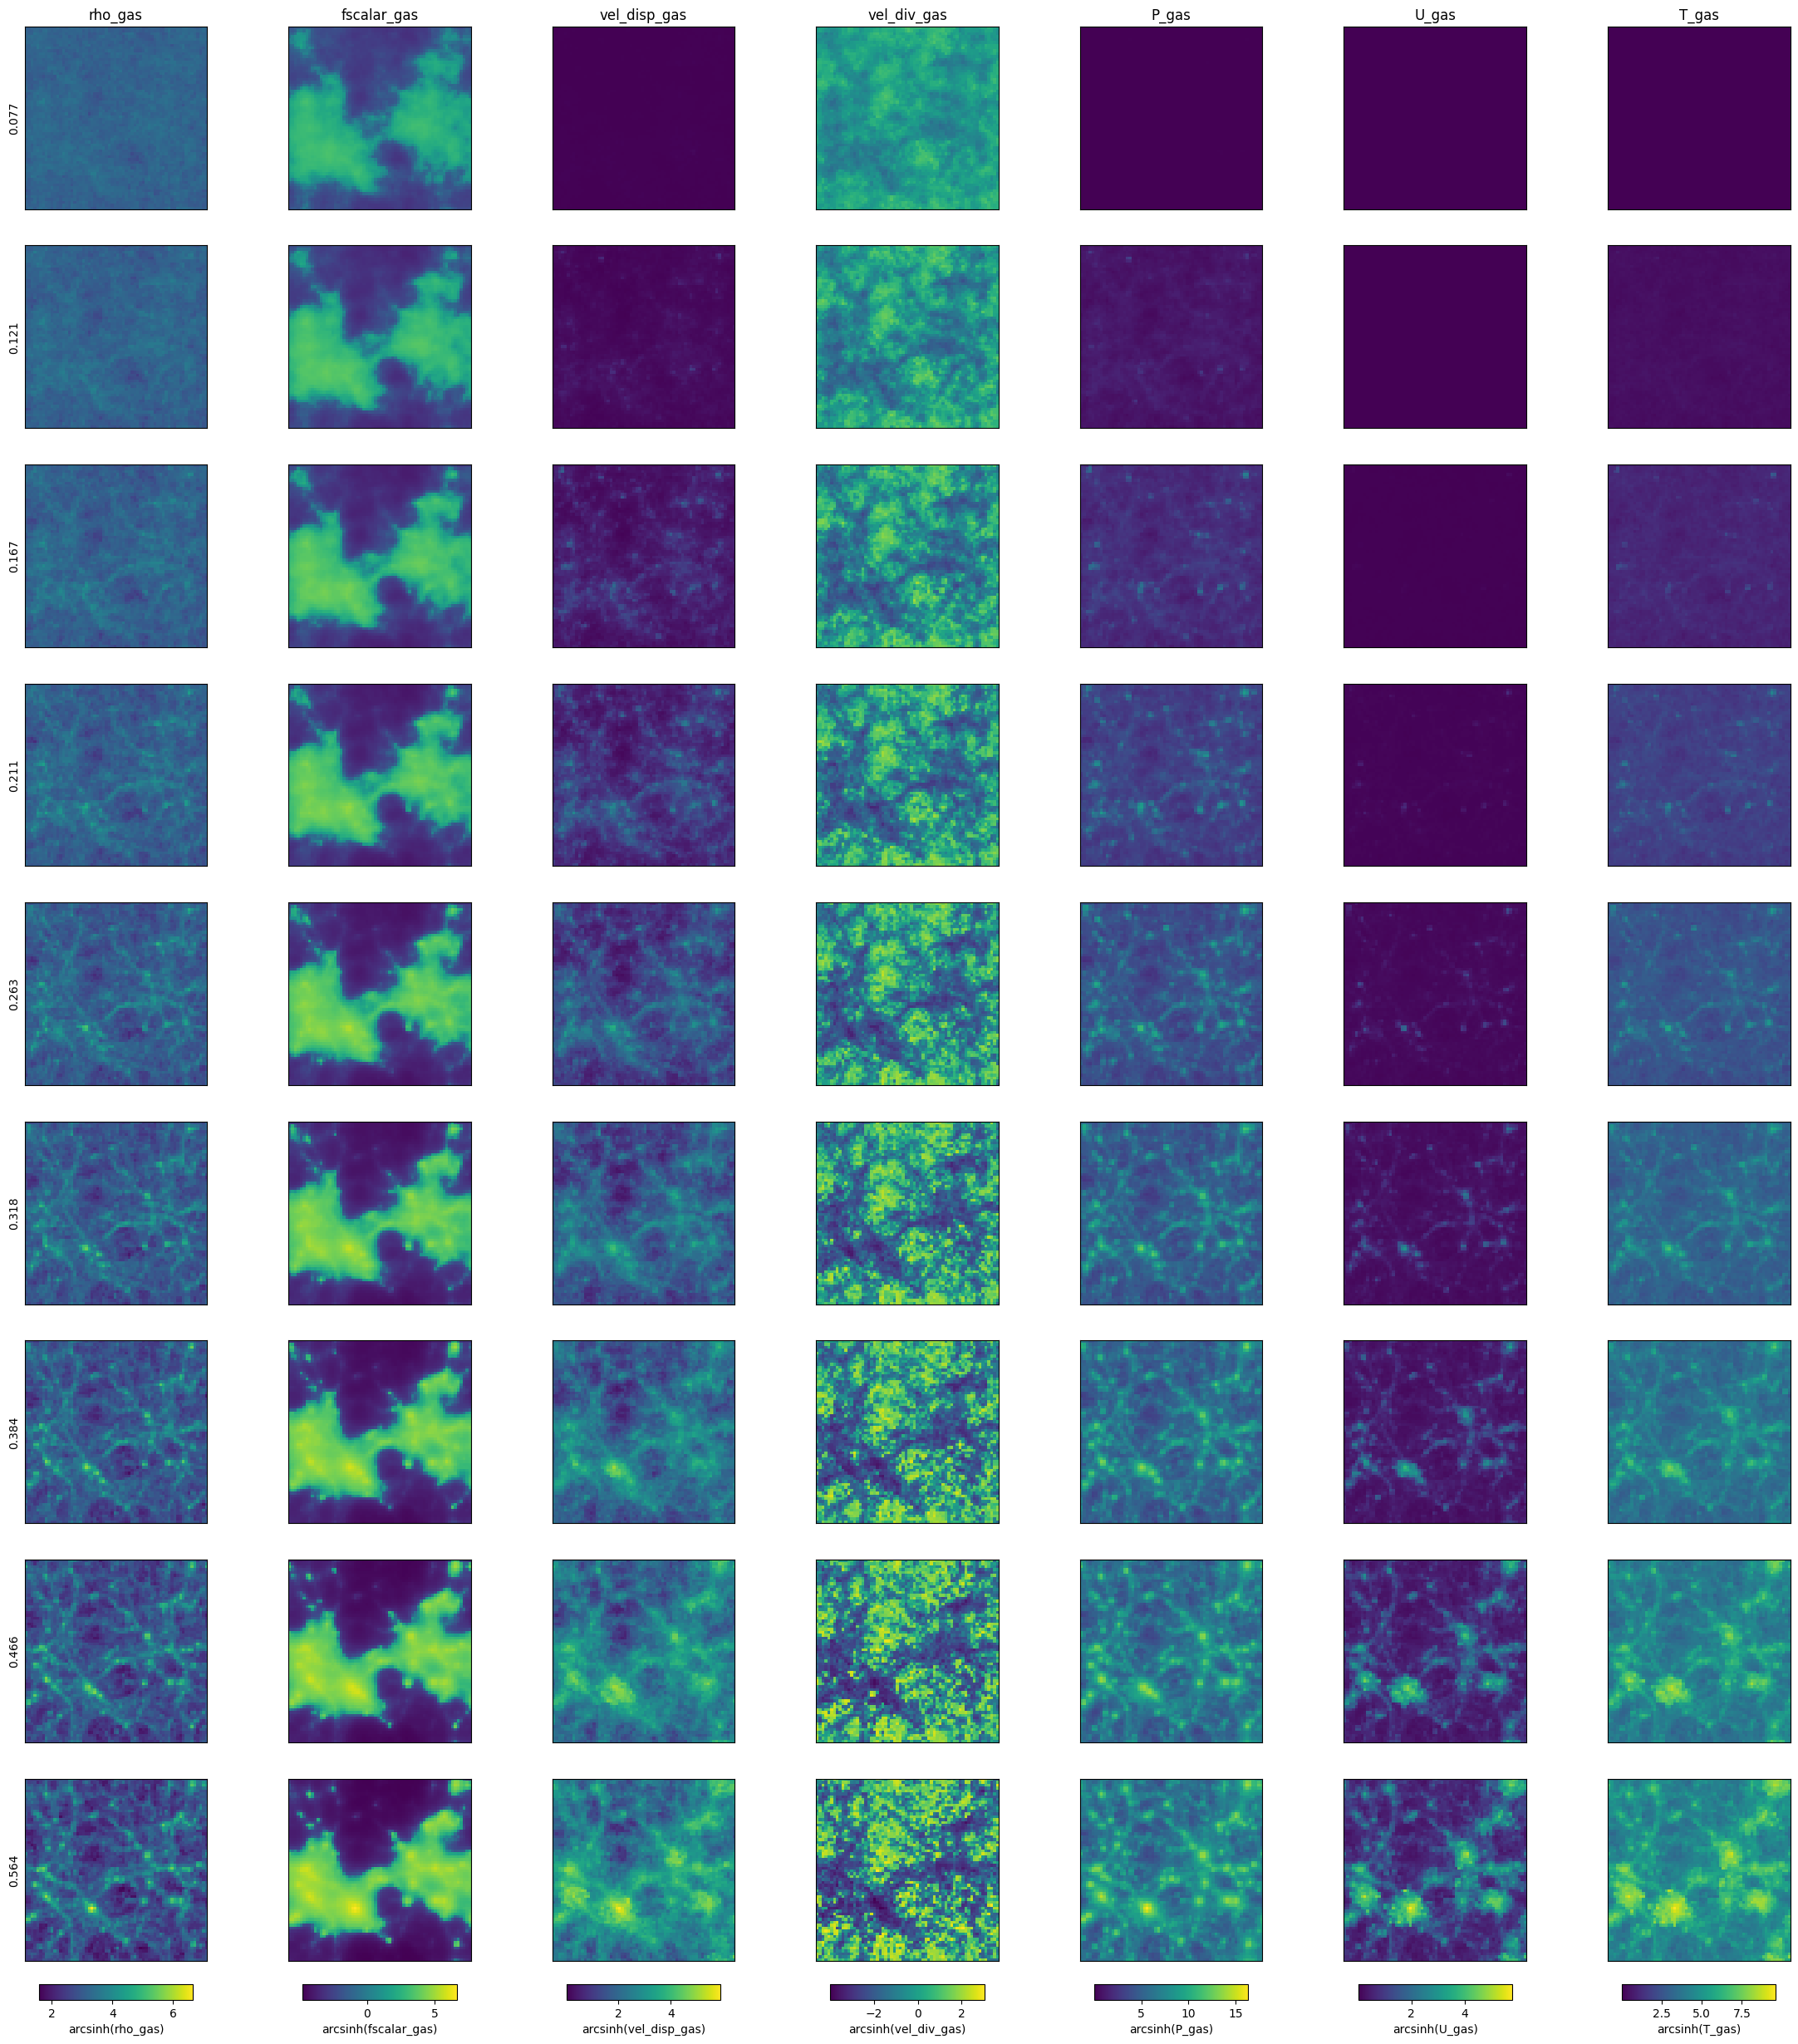

In [10]:
scales, particle_features, field_features = camels.preprocess_snapshots(train_dict)
plotting.plot_gas_features(scales, field_features)

# Network selection

In [11]:
def train_mlp(x_labels, y_labels):
    X, _, Y, _ = data.get_offline_regression_data(train_dict, x_labels=x_labels, y_labels=y_labels)
    X_vali, _, Y_vali, _ = data.get_offline_regression_data(test_dict, x_labels=x_labels, y_labels=y_labels)

    model = MLP(
        X.shape[-1], 
        Y.shape[-1], 
        128, 
        4,
        nnx.Rngs(0),
        0.01,
    )
    
    train_model(
        model,
        (X,),
        Y,
        (X_vali,),
        Y_vali,
    )
    
    return model

# def train_hybrid(x_labels, y_labels):
#     X_particle, X_field, Y = get_data(train_dict, y_labels=y_labels)
#     X_particle_vali, X_field_vali, Y_vali = get_data(test_dict, y_labels=y_labels)
    
#     mlp = MLP(
#         d_in=X_particle.shape[-1], 
#         d_out=8, 
#         d_hidden=64, 
#         n_hidden=4, 
#         rngs=nnx.Rngs(0)
#     )
    
#     cnn = CNN(
#         d_in=X_field.shape[-1], 
#         d_out=8,
#         d_hidden=16,
#         n_hidden=1,
#         kernel_size=(3, 3, 3),
#         strides=1,
#         rngs=nnx.Rngs(0)
#     )
    
#     hybrid = HybridNet(
#         mlp,
#         cnn,
#         d_out=Y.shape[-1],
#         rngs=nnx.Rngs(0),
#         batch_axis=False,
#     )    
    # return hybrid


def train_gnn(x_labels, y_labels):
    X, Y = graph.get_graphs_from_snapshots(
        train_dict,
        x_labels=x_labels,
        y_labels=y_labels,
        k=16, 
        # boxsize=mesh_per_dim
    )
    
    X_vali, Y_vali = graph.get_graphs_from_snapshots(
        test_dict,
        x_labels=x_labels,
        y_labels=y_labels,
        k=16, 
        # boxsize=mesh_per_dim
    )

    model = AttentionGNN(
        d_node=X[0].nodes.shape[-1],
        d_edge=X[0].edges.shape[-1],
        d_query=16,
        n_hidden=4,
        d_out=Y.shape[-1],
        rngs=nnx.Rngs(0),
    )
    
    train_model(
        model,
        (X,),
        Y,
        (X_vali,),
        Y_vali,
    )
    
    return model


# predict P

train=0.2344, vali=0.2536: 100%|██████████| 10000/10000 [10:13<00:00, 16.30it/s]


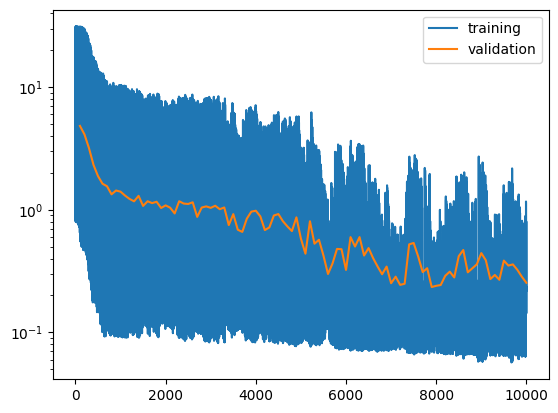

In [12]:
x_labels = ["rho", "fscalar", "vel_disp", "vel_div"]
y_labels = ["P"]

# model = train_mlp(x_labels, y_labels)
model = train_gnn(x_labels, y_labels)

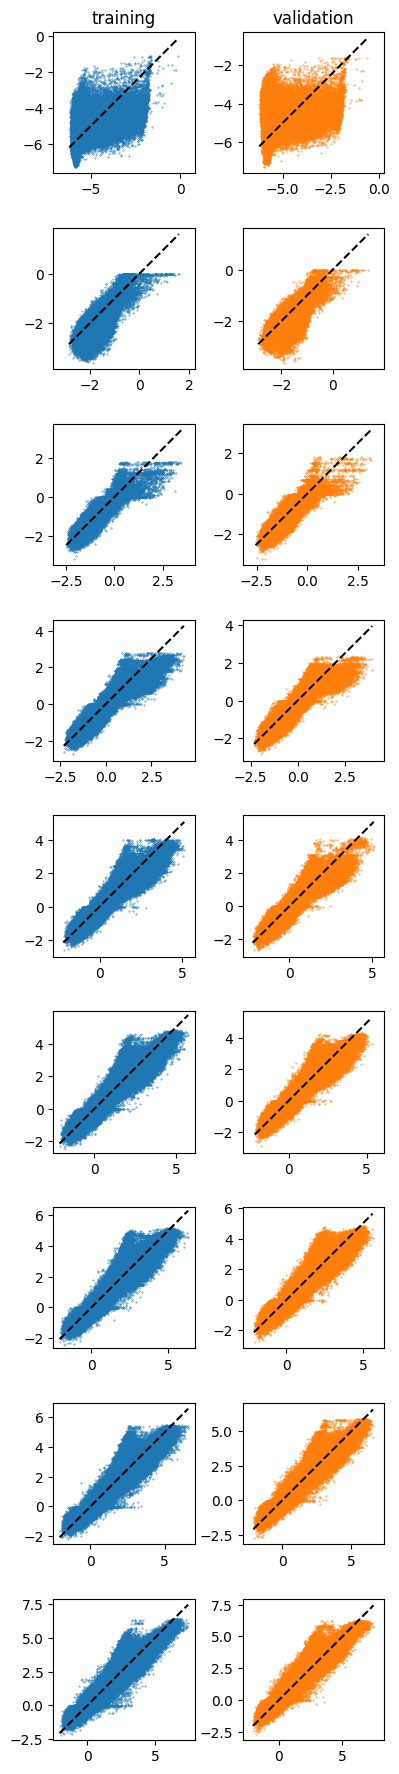

In [13]:
# X, _, Y, _ = data.get_offline_regression_data(train_dict, x_labels=x_labels, y_labels=y_labels)
# X_vali, _, Y_vali, _ = data.get_offline_regression_data(test_dict, x_labels=x_labels, y_labels=y_labels)
    
X, Y = graph.get_graphs_from_snapshots(
    train_dict,
    x_labels=x_labels,
    y_labels=y_labels,
    k=16, 
    # boxsize=mesh_per_dim
)

X_vali, Y_vali = graph.get_graphs_from_snapshots(
    test_dict,
    x_labels=x_labels,
    y_labels=y_labels,
    k=16, 
    # boxsize=mesh_per_dim
)

# pred = model(X)
# pred_vali = model(X_vali)

pred = []
for x in X:
    pred.append(model(x))
pred = jnp.stack(pred, axis=0)
    
pred_vali = []
for x in X_vali:
    pred_vali.append(model(x))
pred_vali = jnp.stack(pred_vali, axis=0)

# log space
plot_preds(pred, Y, pred_vali, Y_vali)

# lin space
# plot_preds(10**pred, train_dict["gas_Ps"], 10**pred_vali, test_dict["gas_Ps"])

In [14]:
# pred = []
# for x in X:
#     pred.append(model(x))
# pred = jnp.stack(pred, axis=0)
    
# pred_vali = []
# for x in X_vali:
#     pred_vali.append(model(x))
# pred_vali = jnp.stack(pred_vali, axis=0)

# plot_preds(pred, Y, pred_vali, Y_vali)

# i = -1
# P_pred = normalized_paint(test_dict["gas_poss"][i], jnp.squeeze(10**pred_vali[i]) + 1)
# P_camels = normalized_paint(test_dict["gas_poss"][i], test_dict["gas_Ps"][i])
# plot_comparison(P_camels, P_pred, pred_label="GNN", suptitle="validation set")

# predict U and compute P from ideal gas law

In [15]:
# gas_U = train_dict["gas_Us"][-1]

# plt.hist(gas_U, bins=50, log=True, density=True)
# plt.show()

# plt.hist(np.log10(gas_U), bins=50, log=True, density=True)
# plt.show()

In [ ]:
x_labels = ["rho", "fscalar", "vel_disp", "vel_div"]
y_labels = ["U"]

# model = train_mlp(x_labels, y_labels)
model = train_gnn(x_labels, y_labels)

train=0.2758, vali=1.1167:  28%|██▊       | 2819/10000 [02:54<07:14, 16.53it/s] 

In [ ]:
# X, _, Y, _ = data.get_offline_regression_data(train_dict, x_labels=x_labels, y_labels=y_labels)
# X_vali, _, Y_vali, _ = data.get_offline_regression_data(test_dict, x_labels=x_labels, y_labels=y_labels)

X, Y = graph.get_graphs_from_snapshots(
    train_dict,
    x_labels=x_labels,
    y_labels=y_labels,
    k=16, 
    # boxsize=mesh_per_dim
)

X_vali, Y_vali = graph.get_graphs_from_snapshots(
    test_dict,
    x_labels=x_labels,
    y_labels=y_labels,
    k=16, 
    # boxsize=mesh_per_dim
)


# U_pred = model(X)
# U_pred_vali = model(X_vali)

U_pred = []
for x in X:
    U_pred.append(model(x))
U_pred = jnp.stack(U_pred, axis=0)
    
U_pred_vali = []
for x in X_vali:
    U_pred_vali.append(model(x))
U_pred_vali = jnp.stack(U_pred_vali, axis=0)


# plot_preds(U_pred, Y, U_pred_vali, Y_vali)
# plot_preds(10**U_pred, 10**Y, 10**U_pred_vali, 10**Y_vali)

plot_preds(jnp.log10(U_pred), jnp.log10(Y), jnp.log10(U_pred_vali), jnp.log10(Y_vali))
plot_preds(U_pred, Y, U_pred_vali, Y_vali)

In [ ]:
gamma = 5.0 / 3.0

P_pred = (gamma - 1.0) * 10**U_pred * train_dict["gas_rhos"][...,jnp.newaxis]
P_pred_vali = (gamma - 1.0) * 10**U_pred_vali * test_dict["gas_rhos"][...,jnp.newaxis]

plot_preds(P_pred, train_dict["gas_Ps"], P_pred_vali, test_dict["gas_Ps"])
plot_preds(jnp.log10(P_pred), jnp.log10(train_dict["gas_Ps"]), jnp.log10(P_pred_vali), jnp.log10(test_dict["gas_Ps"]))

# OLD

In [ ]:
test

In [ ]:
gas_U = train_dict["gas_Us"]
gas_rho = train_dict["gas_rhos"]
gamma = 5.0 / 3.0
gas_P = (gamma - 1.0) * gas_U * gas_rho
box_size = 25
gas_P *= (mesh_per_dim / box_size) ** 3

gas_P_direct = train_dict["gas_Ps"]

In [ ]:
gas_P

In [ ]:
gas_P_direct

In [ ]:
gas_U = train_dict["gas_Us"]
gas_U_pred = jnp.squeeze(10**model(X) - 1)

In [ ]:
gas_U

In [ ]:
gas_U_pred

In [ ]:
gas_U = jnp.squeeze(10**model(X) - 1)

gas_rho = train_dict["gas_rhos"]

# scales, particle_features, field_features = data.preprocess_snapshots(train_dict)
# gas_rho = particle_features["gas_rho"]

gamma = 5.0 / 3.0
gas_P = (gamma - 1.0) * gas_U * gas_rho
box_size = 25
gas_P *= (mesh_per_dim / box_size) ** 3

print(jnp.mean((gas_P - train_dict["gas_Ps"])**2))

In [ ]:
gas_P - train_dict["gas_Ps"]

In [ ]:
train_dict["gas_Us"]

In [ ]:
plt.hist(train_dict["gas_Us"][-1], bins=50, density=False, log=True);

In [ ]:
plt.hist(jnp.log10(train_dict["gas_Us"][-1]+1), bins=50, density=False, log=True);

In [ ]:
10**2.0

In [ ]:
train_dict["gas_rhos"].shape

In [ ]:
train_dict["gas_rhos"]

In [ ]:
particle_features["gas_rho"]

In [ ]:
gas_U = jnp.squeeze(10**model(X) - 1)

scales, particle_features, field_features = data.preprocess_snapshots(train_dict)
# gas_rho = train_dict["gas_rhos"]
gas_rho = particle_features["gas_rho"]

gamma = 5.0 / 3.0
gas_P = (gamma - 1.0) * gas_U * gas_rho

print(jnp.mean((gas_P - train_dict["gas_Ps"])**2))

In [ ]:
plt.hist(gas_P[-1], bins=50);

In [ ]:
plt.hist(train_dict["gas_Ps"][-1], bins=50);

In [ ]:
train_dict["gas_Ps"][-1]/gas_P[-1]

In [ ]:
plt.hist(train_dict["gas_Ps"][-1]/gas_P[-1], bins=50);

In [ ]:
diff = gas_P - train_dict["gas_Ps"]

plt.hist(diff[-1])

In [ ]:
diff.shape

In [ ]:
gas_P - train_dict["gas_Ps"]

In [ ]:
gas_P_camels = train_dict["gas_Ps"]

In [ ]:
gas_P_camels

In [ ]:
gas_P

In [ ]:
gas_P.shape

In [ ]:
gas_U.shape

In [ ]:
                P_gas = cic_paint(jnp.zeros([mesh_per_dim] * 3), gas_pos, (gamma - 1.0) * gas_U * gas_mass)
                gas_P = cic_read(P_gas, gas_pos)


In [ ]:

i = -1
P_pred = normalized_paint(test_dict["gas_poss"][i], jnp.squeeze(10**pred_vali[i]) + 1)
P_camels = normalized_paint(test_dict["gas_poss"][i], test_dict["gas_Ps"][i])

plot_comparison(P_camels, P_pred, pred_label="MLP", suptitle="validation set")
